## Problem Statement
> Develop a binary classification model that predicts whether an observation belongs to the diabetic or non-diabetic class based on the available clinical features.

## Dataset
The dataset used is the Pima Indian Diabetes Database from Kaggle. The link is https://www.kaggle.com/datasets/mragpavank/diabetes

## Evaluation
> Primary evaluation metric: Recall. The goal is to minimize false negatives because failing to identify a patient who may have diabetes is considered more costly than generating a false positive. A target recall of 90% will be investigated, while also monitoring precision and other relevant metrics.

## Features
1. Pregnancies: Number of times pregnant.
2. Glucose: Plasma glucose concentration from a oral glucose tolerance test.
3. Blood Pressure: Diastolic blood pressure (mm Hg).
4. Skin Thickness: Triceps skin fold thickness (mm).
5. Insulin: 2-Hour serum insulin (μU/ml).
6. BMI: Body mass index (weight in kg/(height in m)²).
7. Diabetes Pedigree Function: Score providing information on diabetes history in relatives.
8. Age: Age in years.
9. Outcome (0 for non-diabetic, 1 for diabetic)

## Some Key EDA Findings

1. Class distribution: Outcome 0 accounts for approximately 65% of observations, while Outcome 1 accounts for approximately 35%.

2. Missing/invalid values: Several predictors contain zero values that may represent missing measurements, particularly Insulin (48.7%) and SkinThickness (29.6%).

3. Glucose: Outcome 1 observations generally have higher glucose values than Outcome 0 observations.

4. BMI: Outcome 1 observations tend to have higher BMI values, although substantial overlap exists.

5. Age: Age is positively skewed, with substantially more younger observations.

6. Insulin: Insulin has substantial dispersion and extreme values and will require further investigation during preprocessing.

7. Insulin: 51% of the Diabetic group (Outcome 1) has zero values while 47% of the Non-diabetic (Outcome 0) group has zero values

These findings will guide the data-cleaning and preprocessing decisions in the next stage.

### This is a remodel of the modelling notebook

## Models used for baseline
1. DummyClassifier: Serves as a sanity check for other models
2. LogisticRegression: Serves as a baseline to explore linear relationships
3. KNN: Useful for small datasets
4. SVC: To explore the non-linear boundaries
5. DecisionTreeClassifier: Tree-based Baseline for handling non-linear relationships
6. RandomForestClassifier: It is a more powerful tree-based model, less prone to overfitting

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_validate, cross_val_score, StratifiedKFold, RandomizedSearchCV, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_csv('../data/diabetes.csv')

## Creating a Baseline Model

In [3]:
X = df.drop('Outcome', axis=1)
y = df.Outcome

In [4]:
# Stratification is used because the target variable is imbalanced
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [5]:
# Columns with encoded 0 missing values
zero_categories = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Remaining Columns
others_column = [col for col in X_train.columns if col not in zero_categories]

In [6]:
# Preprocessing steps
# Impute strategy - Median
# Scaler - StandardScaler

zero = Pipeline(steps=[
    ('impute', SimpleImputer(missing_values=0, strategy='median')),
    ('scaler', StandardScaler())
])
others = Pipeline(steps=[
    ('scaler', StandardScaler())
])

preprocessing = ColumnTransformer(transformers=[
    ('zero', zero, zero_categories),
    ('others', others, others_column)
], remainder='passthrough')

preprocessing_without_scale = ColumnTransformer(transformers=[
    ('impute', SimpleImputer(missing_values=0, strategy='median'), zero_categories)
], remainder='passthrough')

In [7]:
models = {
    'dummy classifier': DummyClassifier(strategy='stratified', random_state=42),
    'logistic regression': Pipeline(steps=[('preprocessing', preprocessing), ('model', LogisticRegression(random_state=42))]),
    'KNN': Pipeline(steps=[('preprocesing', preprocessing), ('model', KNeighborsClassifier(n_neighbors=5))]),
    'SVC': Pipeline(steps=[('preprocesing', preprocessing), ('model', SVC(probability=True, random_state=42))]),
    'Decision Tree': Pipeline(steps=[('preprocessing', preprocessing_without_scale), ('model', DecisionTreeClassifier(random_state=42))]),
    'Random Forest': Pipeline(steps=[('preprocessing', preprocessing_without_scale), ('model', RandomForestClassifier(random_state=42))])
}

In [8]:
# Scoring metrics
scoring = {
    'accuracy': 'accuracy',
     "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "balanced_accuracy": "balanced_accuracy",
    "average_precision": "average_precision"
}

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [10]:
results = {}

for model, pipeline in models.items():
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        verbose=2
    )

    results[model] = {
        "Accuracy Mean": scores["test_accuracy"].mean(),
        # "Accuracy Std": scores["test_accuracy"].std(),
        
        "Precision Mean": scores["test_precision"].mean(),
        # "Precision Std": scores["test_precision"].std(),
        
        "Recall Mean": scores["test_recall"].mean(),
        # "Recall Std": scores["test_recall"].std(),
        
        "F1 Mean": scores["test_f1"].mean(),
        # "F1 Std": scores["test_f1"].std(),
        
        "ROC-AUC Mean": scores["test_roc_auc"].mean(),
        # "ROC-AUC Std": scores["test_roc_auc"].std(),
        
        "Balanced_Accuracy Mean": scores["test_balanced_accuracy"].mean(),
        # "Balanced_Accuracy Std": scores["test_balanced_accuracy"].std(),
        
        "Average_precision Mean": scores["test_average_precision"].mean(),
        # "Average_precision Std": scores["test_average_precision"].std()
    }

[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.1s finished


[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.4s finished


[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s


...

[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.9s finished


[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.3s finished


[CV] END .................................................... total time=   0.4s
[CV] END .................................................... total time=   0.4s
[CV] END .................................................... total time=   0.4s
[CV] END .................................................... total time=   0.4s
[CV] END .................................................... total time=   0.4s


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    2.4s finished


In [11]:
results_df = pd.DataFrame(results).T

In [12]:
results_df

,Accuracy Mean,Precision Mean,Recall Mean,F1 Mean,ROC-AUC Mean,Balanced_Accuracy Mean,Average_precision Mean
dummy classifier,0.578155,0.390244,0.373754,0.381813,0.530627,0.530627,0.364968
logistic regression,0.788231,0.763808,0.574751,0.654545,0.843364,0.738625,0.747125
KNN,0.729588,0.636708,0.565449,0.593861,0.784332,0.691474,0.616013
SVC,0.780128,0.741534,0.584164,0.648462,0.833308,0.734582,0.726241
Decision Tree,0.679168,0.539606,0.546733,0.542422,0.648367,0.648367,0.453403
Random Forest,0.760589,0.693317,0.579734,0.627312,0.816324,0.718617,0.703715


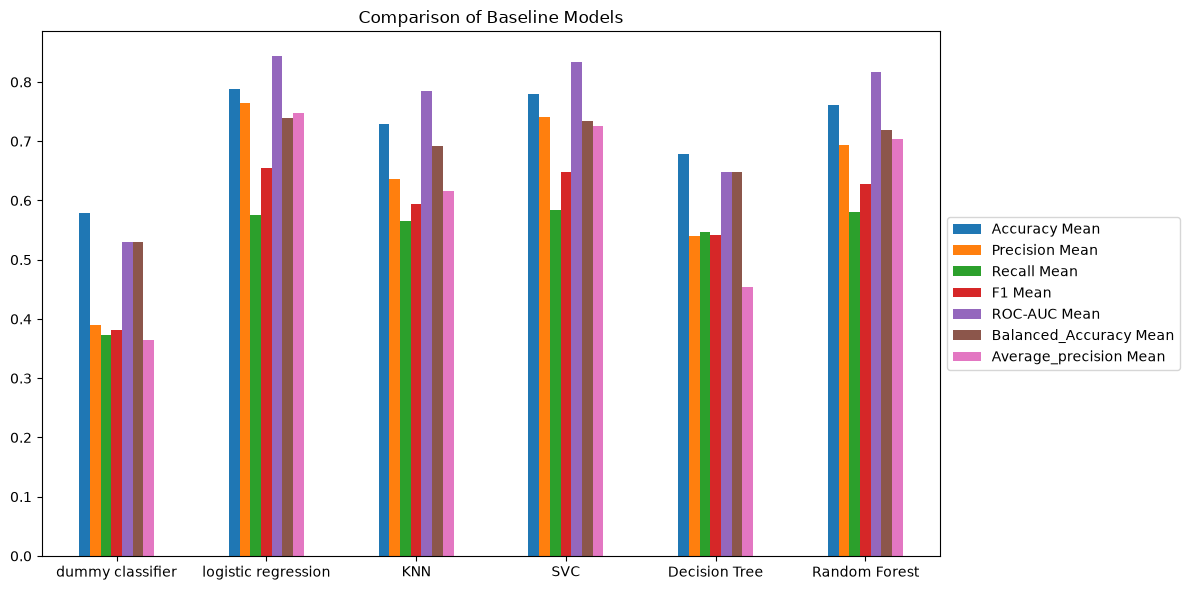

In [13]:
ax = results_df.plot.bar(
    title='Comparison of Baseline Models',
    figsize=(12, 6),
    rot=0
)

ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()

Using the current baseline configurations, SVC, Logistic Regression and Random Forest performed strongest according to Average Precision.

## Hyperparameter Tuning

### Logistic Regression

In [18]:
lr_model = Pipeline(steps=[('preprocessing', preprocessing), ('model', LogisticRegression(random_state=42))])

In [34]:
grid = [
    {"model__C": [0.001, 0.01, 0.1, 1, 10, 100],
     "model__l1_ratio" : [0],
    "model__solver": ['lbfgs', 'liblinear'],
     "model__max_iter": range(10, 500, 100),
    "model__class_weight": [None, 'balanced']},

    {"model__C": [0.001, 0.01, 0.1, 1, 10, 100],
     "model__l1_ratio" : [1],
    "model__solver": ['saga', 'liblinear'],
     "model__max_iter": range(10, 500, 100),
    "model__class_weight": [None, 'balanced']}
]

In [39]:
def RandSearch(model, grid):
    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=grid,
        n_iter=50,
        cv=cv,
        verbose=2,
        scoring='recall'
    )
    
    search.fit(X_train, y_train)

    return search

def GridSearch(model, grid):
    search = GridSearchCV(
        estimator=model,
        param_grid=grid,
        cv=cv,
        verbose=2,
        scoring='recall'
    )
    
    search.fit(X_train, y_train)

    return search

In [40]:
lr_search = RandSearch(lr_model, grid)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END model__C=10, model__class_weight=balanced, model__l1_ratio=1, model__max_iter=310, model__solver=saga; total time=   0.0s
[CV] END model__C=10, model__class_weight=balanced, model__l1_ratio=1, model__max_iter=310, model__solver=saga; total time=   0.0s
[CV] END model__C=10, model__class_weight=balanced, model__l1_ratio=1, model__max_iter=310, model__solver=saga; total time=   0.0s
[CV] END model__C=10, model__class_weight=balanced, model__l1_ratio=1, model__max_iter=310, model__solver=saga; total time=   0.0s
[CV] END model__C=10, model__class_weight=balanced, model__l1_ratio=1, model__max_iter=310, model__solver=saga; total time=   0.0s
[CV] END model__C=100, model__class_weight=None, model__l1_ratio=1, model__max_iter=110, model__solver=liblinear; total time=   0.0s
[CV] END model__C=100, model__class_weight=None, model__l1_ratio=1, model__max_iter=110, model__solver=liblinear; total time=   0.0s
[CV] END model__C

C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\svm\_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\svm\_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\svm\_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\svm\_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\svm\_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[CV] END model__C=100, model__class_weight=None, model__l1_ratio=1, model__max_iter=10, model__solver=liblinear; total time=   0.0s
[CV] END model__C=100, model__class_weight=None, model__l1_ratio=1, model__max_iter=10, model__solver=liblinear; total time=   0.0s
[CV] END model__C=100, model__class_weight=None, model__l1_ratio=1, model__max_iter=10, model__solver=liblinear; total time=   0.0s
[CV] END model__C=100, model__class_weight=None, model__l1_ratio=1, model__max_iter=10, model__solver=liblinear; total time=   0.0s
[CV] END model__C=100, model__class_weight=None, model__l1_ratio=1, model__max_iter=10, model__solver=liblinear; total time=   0.0s
[CV] END model__C=0.001, model__class_weight=None, model__l1_ratio=1, model__max_iter=110, model__solver=liblinear; total time=   0.0s
[CV] END model__C=0.001, model__class_weight=None, model__l1_ratio=1, model__max_iter=110, model__solver=liblinear; total time=   0.0s
[CV] END model__C=0.001, model__class_weight=None, model__l1_ratio=1, 

C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END model__C=100, model__class_weight=balanced, model__l1_ratio=1, model__max_iter=10, model__solver=saga; total time=   0.0s
[CV] END model__C=100, model__class_weight=balanced, model__l1_ratio=1, model__max_iter=10, model__solver=saga; total time=   0.0s
[CV] END model__C=100, model__class_weight=balanced, model__l1_ratio=1, model__max_iter=10, model__solver=saga; total time=   0.0s
[CV] END model__C=100, model__class_weight=balanced, model__l1_ratio=0, model__max_iter=10, model__solver=liblinear; total time=   0.0s
[CV] END model__C=100, model__class_weight=balanced, model__l1_ratio=0, model__max_iter=10, model__solver=liblinear; total time=   0.0s
[CV] END model__C=100, model__class_weight=balanced, model__l1_ratio=0, model__max_iter=10, model__solver=liblinear; total time=   0.0s
[CV] END model__C=100, model__class_weight=balanced, model__l1_ratio=0, model__max_iter=10, model__solver=liblinear; total time=   0.0s
[CV] END model__C=100, model__class_weight=balanced, model__l1_

...

[CV] END model__C=100, model__class_weight=balanced, model__l1_ratio=1, model__max_iter=10, model__solver=liblinear; total time=   0.0s
[CV] END model__C=100, model__class_weight=balanced, model__l1_ratio=1, model__max_iter=10, model__solver=liblinear; total time=   0.0s
[CV] END model__C=100, model__class_weight=None, model__l1_ratio=0, model__max_iter=210, model__solver=lbfgs; total time=   0.0s
[CV] END model__C=100, model__class_weight=None, model__l1_ratio=0, model__max_iter=210, model__solver=lbfgs; total time=   0.0s
[CV] END model__C=100, model__class_weight=None, model__l1_ratio=0, model__max_iter=210, model__solver=lbfgs; total time=   0.0s
[CV] END model__C=100, model__class_weight=None, model__l1_ratio=0, model__max_iter=210, model__solver=lbfgs; total time=   0.0s
[CV] END model__C=100, model__class_weight=None, model__l1_ratio=0, model__max_iter=210, model__solver=lbfgs; total time=   0.0s
[CV] END model__C=0.1, model__class_weight=None, model__l1_ratio=0, model__max_iter

C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\svm\_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\svm\_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[CV] END model__C=1, model__class_weight=None, model__l1_ratio=1, model__max_iter=10, model__solver=liblinear; total time=   0.0s
[CV] END model__C=1, model__class_weight=None, model__l1_ratio=1, model__max_iter=10, model__solver=liblinear; total time=   0.0s
[CV] END model__C=100, model__class_weight=None, model__l1_ratio=0, model__max_iter=310, model__solver=liblinear; total time=   0.0s
[CV] END model__C=100, model__class_weight=None, model__l1_ratio=0, model__max_iter=310, model__solver=liblinear; total time=   0.0s
[CV] END model__C=100, model__class_weight=None, model__l1_ratio=0, model__max_iter=310, model__solver=liblinear; total time=   0.0s
[CV] END model__C=100, model__class_weight=None, model__l1_ratio=0, model__max_iter=310, model__solver=liblinear; total time=   0.0s
[CV] END model__C=100, model__class_weight=None, model__l1_ratio=0, model__max_iter=310, model__solver=liblinear; total time=   0.0s
[CV] END model__C=0.01, model__class_weight=balanced, model__l1_ratio=1, mo

C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END model__C=0.01, model__class_weight=balanced, model__l1_ratio=1, model__max_iter=10, model__solver=saga; total time=   0.0s
[CV] END model__C=0.01, model__class_weight=balanced, model__l1_ratio=1, model__max_iter=10, model__solver=saga; total time=   0.0s
[CV] END model__C=0.01, model__class_weight=None, model__l1_ratio=1, model__max_iter=410, model__solver=saga; total time=   0.0s
[CV] END model__C=0.01, model__class_weight=None, model__l1_ratio=1, model__max_iter=410, model__solver=saga; total time=   0.0s
[CV] END model__C=0.01, model__class_weight=None, model__l1_ratio=1, model__max_iter=410, model__solver=saga; total time=   0.0s
[CV] END model__C=0.01, model__class_weight=None, model__l1_ratio=1, model__max_iter=410, model__solver=saga; total time=   0.0s
[CV] END model__C=0.01, model__class_weight=None, model__l1_ratio=1, model__max_iter=410, model__solver=saga; total time=   0.0s
[CV] END model__C=0.001, model__class_weight=None, model__l1_ratio=1, model__max_iter=10, m

In [41]:
lr_search.best_score_

np.float64(0.7992248062015503)

In [42]:
lr_search.best_params_

{'model__solver': 'liblinear',
 'model__max_iter': 410,
 'model__l1_ratio': 0,
 'model__class_weight': 'balanced',
 'model__C': 0.001}

In [43]:
grid_lr = [
    {"model__C": [0.001, 0.01, 0.1],
     "model__l1_ratio" : [0],
    "model__solver": ['liblinear'],
     "model__max_iter": [300, 350, 400, 450],
    "model__class_weight": ['balanced']},
]

lr_grsearch = GridSearch(lr_model, grid_lr)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END model__C=0.001, model__class_weight=balanced, model__l1_ratio=0, model__max_iter=300, model__solver=liblinear; total time=   0.0s
[CV] END model__C=0.001, model__class_weight=balanced, model__l1_ratio=0, model__max_iter=300, model__solver=liblinear; total time=   0.0s
[CV] END model__C=0.001, model__class_weight=balanced, model__l1_ratio=0, model__max_iter=300, model__solver=liblinear; total time=   0.0s
[CV] END model__C=0.001, model__class_weight=balanced, model__l1_ratio=0, model__max_iter=300, model__solver=liblinear; total time=   0.0s
[CV] END model__C=0.001, model__class_weight=balanced, model__l1_ratio=0, model__max_iter=300, model__solver=liblinear; total time=   0.0s
[CV] END model__C=0.001, model__class_weight=balanced, model__l1_ratio=0, model__max_iter=350, model__solver=liblinear; total time=   0.0s
[CV] END model__C=0.001, model__class_weight=balanced, model__l1_ratio=0, model__max_iter=350, model__sol

In [44]:
lr_grsearch.best_score_

np.float64(0.7992248062015503)

In [45]:
lr_grsearch.best_params_

{'model__C': 0.001,
 'model__class_weight': 'balanced',
 'model__l1_ratio': 0,
 'model__max_iter': 300,
 'model__solver': 'liblinear'}

In [64]:
def cv_evaluate(model):
    results = {}
    scores = cross_validate(
            model,
            X_train,
            y_train,
            cv=cv,
            scoring=scoring,
            verbose=2
        )
    
    results = {
            "Accuracy Mean": scores["test_accuracy"].mean(),        
            "Precision Mean": scores["test_precision"].mean(),
            "Recall Mean": scores["test_recall"].mean(),        
            "F1 Mean": scores["test_f1"].mean(),        
            "ROC-AUC Mean": scores["test_roc_auc"].mean(),        
            "Balanced_Accuracy Mean": scores["test_balanced_accuracy"].mean(),        
            "Average_precision Mean": scores["test_average_precision"].mean()
        }

    return results

In [65]:
lr_eval = cv_evaluate(lr_grsearch.best_estimator_)

[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.4s finished


In [80]:
comparison = pd.DataFrame([lr_eval], index=['LogisticRegression'])

In [81]:
comparison

,Accuracy Mean,Precision Mean,Recall Mean,F1 Mean,ROC-AUC Mean,Balanced_Accuracy Mean,Average_precision Mean
LogisticRegression,0.727962,0.580711,0.799225,0.671667,0.833045,0.744612,0.71445
